In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fardinbari26/double-per/data set 1053.xlsx


In [4]:
# ─── Install Dependencies ───
!pip install -q xgboost lightgbm catboost
print("Environment ready.")

Environment ready.


In [26]:
# ─── Imports ───
import warnings, time, gc
warnings.filterwarnings("ignore")

import glob, shap
from pathlib import Path

# --- Import Data Analysis & Visualization Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# --- Import Data Splitting, Cross-Validation & Feature Scaling ---
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# --- Import Machine Learning Classification Models ---
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# --- Import Classification Evaluation Metrics ---
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)


# ─── Plot Configuration ───
sns.set_style("whitegrid")
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 600, "savefig.bbox": "tight", "font.size": 11})
SEED = 42
np.random.seed(SEED)

print("✅ All libraries loaded!")
print("Environment ready.")

✅ All libraries loaded!
Environment ready.


In [9]:
excel_path = "/kaggle/input/datasets/fardinbari26/double-per/data set 1053.xlsx"
csv_path = "/kaggle/working/data_set_1053.csv"

df = pd.read_excel(excel_path)

df.to_csv(csv_path, index=False)

print("✅ CSV converted successfully!")
print("Saved at:", csv_path)
df = pd.read_csv("/kaggle/working/data_set_1053.csv")

print("✅ Dataset loaded!")

✅ CSV converted successfully!
Saved at: /kaggle/working/data_set_1053.csv
✅ Dataset loaded!


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1053 entries, 0 to 1052
Data columns (total 57 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   A2BBX6                       1053 non-null   object 
 1   A                            1053 non-null   object 
 2   B1                           1053 non-null   object 
 3   B2                           1053 non-null   object 
 4   X                            1053 non-null   object 
 5   band_gap                     1053 non-null   float64
 6   formation_energy             1053 non-null   float64
 7   A_ionic_radius               1053 non-null   float64
 8   B1_ionic_radius              1053 non-null   float64
 9   B2_ionic_radius              1053 non-null   float64
 10  X_ionic_radius               1053 non-null   float64
 11  A_electronegativity          1053 non-null   float64
 12  B1_electronegativity         1053 non-null   float64
 13  B2_electronegativi

In [11]:
df.describe()

,band_gap,formation_energy,A_ionic_radius,B1_ionic_radius,B2_ionic_radius,X_ionic_radius,A_electronegativity,B1_electronegativity,B2_electronegativity,X_electronegativity,...,A_van_der_waals_radius,B1_van_der_waals_radius,B2_van_der_waals_radius,X_van_der_waals_radius,A_third_ionization_energy,B1_third_ionization_energy,B2_third_ionization_energy,X_third_ionization_energy,tolerance_factor,octahedral_factor
count,1053.000000,1053.000000,1053.000000,1053.000000,1053.000000,1053.000000,1053.000000,1053.000000,1053.000000,1053.000000,...,1053.000000,1053.000000,1053.000000,1053.000000,1053.000000,1053.000000,1053.000000,1053.000000,1053.000000,1053.000000
mean,1.776702,-2.793781,1.392227,0.950318,0.872937,1.296572,0.989886,1.485166,1.723903,3.469839,...,2.628718,2.146116,2.136809,1.539497,37.675464,39.293013,31.862907,54.189033,0.836506,0.617330
std,1.824059,0.512201,0.233146,0.234740,0.248197,0.136699,0.268955,0.412960,0.421150,0.210544,...,0.364455,0.216283,0.144265,0.078565,12.788156,25.380610,18.936068,5.724990,0.071024,0.150377
min,0.000000,-4.009000,0.520000,0.410000,0.300000,1.190000,0.790000,0.820000,0.930000,2.580000,...,1.730000,1.530000,1.520000,1.470000,19.177300,19.177300,19.177300,29.570000,0.476657,0.269737
25%,0.000000,-3.107186,1.172000,0.765000,0.750000,1.260000,0.890000,1.140000,1.380000,3.440000,...,2.430000,2.000000,2.060000,1.520000,33.195000,24.756839,24.756839,54.935540,0.793630,0.513158
50%,1.472200,-2.826556,1.330000,0.885000,0.780000,1.260000,0.930000,1.500000,1.660000,3.440000,...,2.490000,2.130000,2.150000,1.520000,35.843800,30.651000,27.130000,54.935540,0.835003,0.572368
75%,3.140000,-2.494000,1.490000,1.090000,0.900000,1.260000,1.000000,1.880000,2.100000,3.440000,...,2.680000,2.270000,2.220000,1.520000,42.883530,37.468000,30.202640,54.935540,0.882718,0.699342
max,7.617300,0.052482,1.810000,2.070000,2.070000,2.060000,2.330000,2.660000,3.440000,3.980000,...,3.430000,3.030000,2.490000,1.980000,122.454359,153.896205,153.896205,62.707980,1.081264,1.361842


In [12]:
Target = "band_gap"
print("Target ready.")

Target ready.


In [14]:
print(f"Dataset shape : {df.shape}")
# print(f"Class balance : {dict(df[Target].value_counts())}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows  : {df.duplicated().sum()}")
print(f"Dtypes        : {dict(df.dtypes.value_counts())}")

Dataset shape : (1053, 57)
Missing values: 0
Duplicate rows  : 0
Dtypes        : {dtype('float64'): np.int64(48), dtype('O'): np.int64(5), dtype('int64'): np.int64(4)}


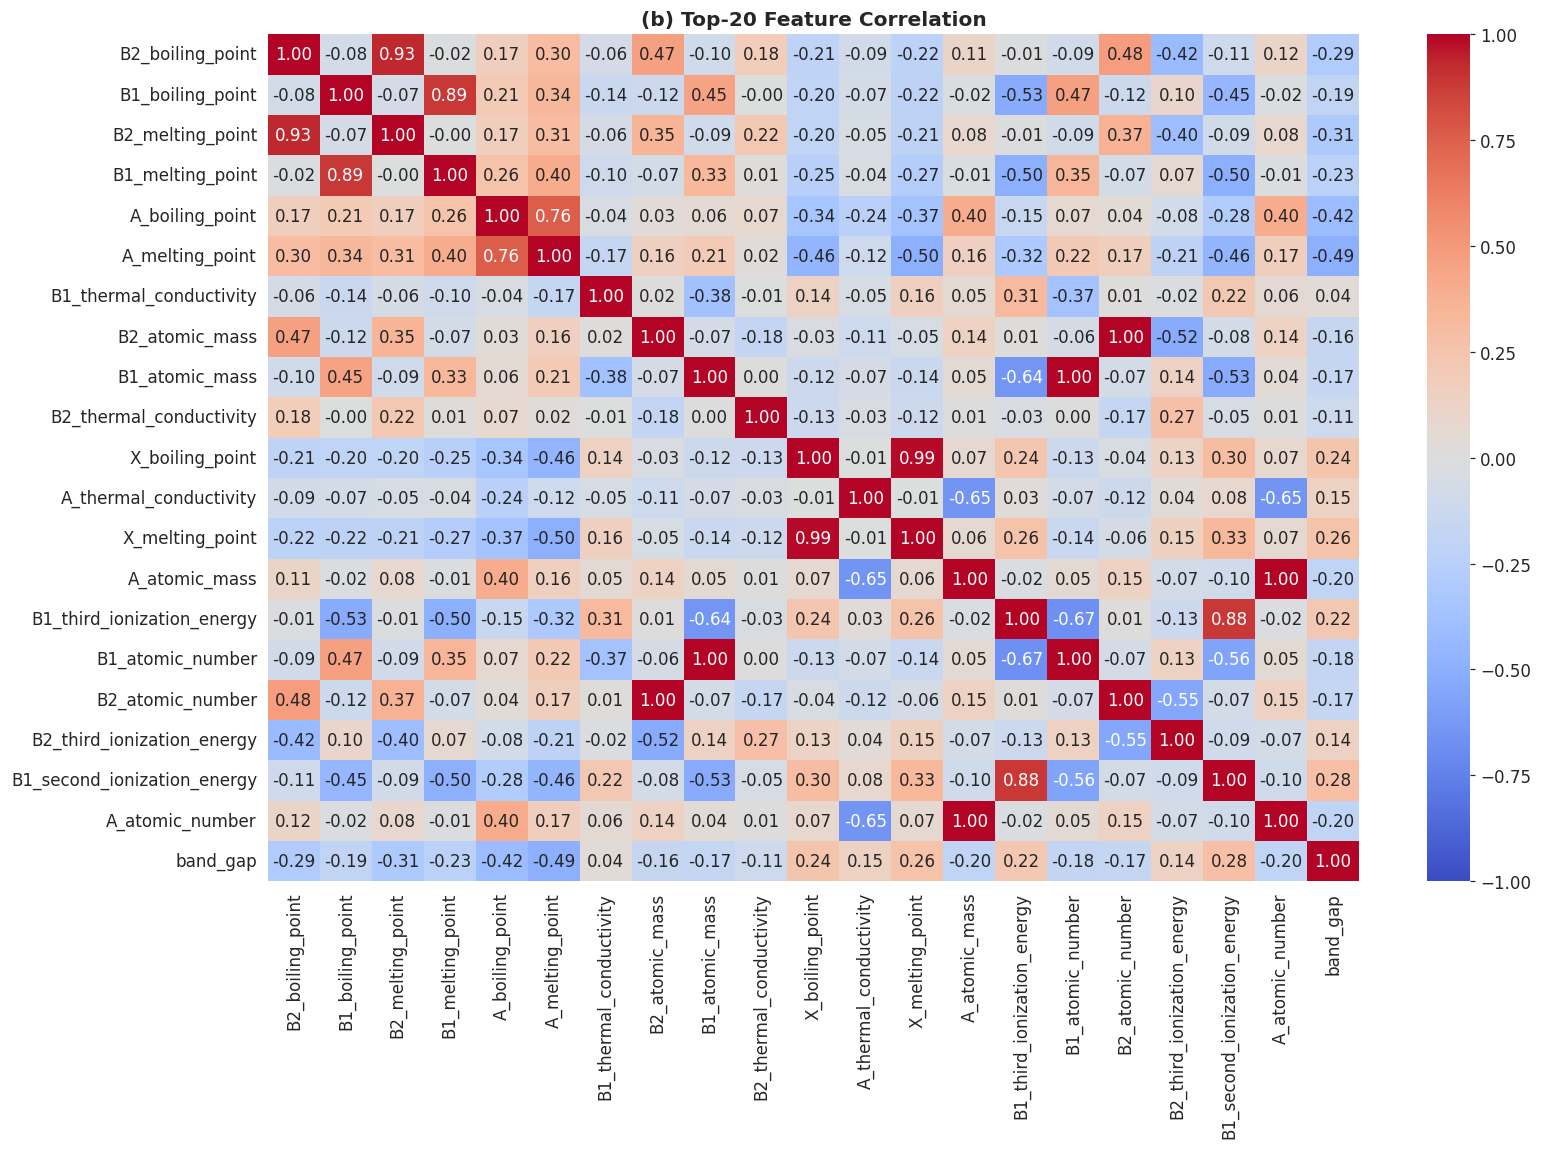

In [16]:
# ─── Exploratory Data Analysis (EDA) ───
num_df = df.select_dtypes(include="number")
fig, ax = plt.subplots(figsize=(16,10))

# (b) Correlation Heatmap (Top-20 variable features)
top_feats = num_df.drop(columns=Target).std().nlargest(20).index.tolist()
corr = num_df[top_feats + [Target]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt='.2f', ax=ax)
ax.set_title("(b) Top-20 Feature Correlation", fontweight="bold")
# Save the figure
plt.savefig(
    "(b) Top-20 Feature Correlation.png",
    dpi=600,
    bbox_inches="tight"
)

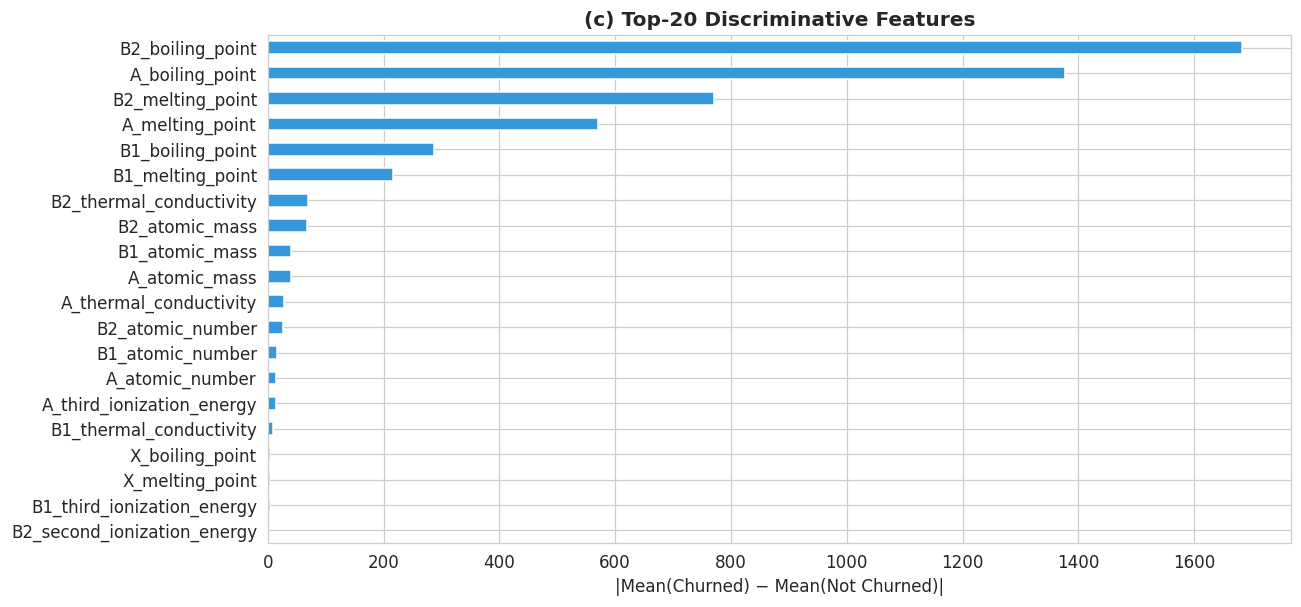

In [17]:
# ─── Exploratory Data Analysis (EDA) ───
num_df = df.select_dtypes(include="number")
fig, ax = plt.subplots(figsize=(12,6))

# (c) Mean Absolute Difference per Feature
grp_mean = num_df.groupby(Target).mean()
mean_diff = (grp_mean.iloc[1] - grp_mean.iloc[0]).abs().sort_values(ascending=False).head(20)
mean_diff.sort_values().plot.barh(ax=ax, color="#3498db", edgecolor="white")
ax.set_title("(c) Top-20 Discriminative Features", fontweight="bold")
ax.set_xlabel("|Mean(Churned) − Mean(Not Churned)|")
# Save the figure
plt.savefig(
    "(c) Top-20 Discriminative Features.png",
    dpi=600,
    bbox_inches="tight"
)

In [18]:
# ─── Feature Engineering & Selection ───
X = df.drop(columns=Target).select_dtypes(include="number")
y = df[Target]

n_initial = X.shape[1]

# Step 1: Remove zero-variance features
zero_var = X.columns[X.std() == 0].tolist()
X = X.drop(columns=zero_var)

# Step 2: Remove highly correlated features (|r| > 0.95)
corr_mat = X.corr().abs()
upper_tri = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
redundant = [c for c in upper_tri.columns if any(upper_tri[c] > 0.95)]
X = X.drop(columns=redundant)

print(f"Features: {n_initial} → {X.shape[1]} "
      f"(removed {len(zero_var)} zero-var, {len(redundant)} redundant)")
pd.Series({"features": X.shape[1], "samples": len(X), "default_rate": round(y.mean(), 4)})

Features: 51 → 40 (removed 0 zero-var, 11 redundant)


features          40.0000
samples         1053.0000
default_rate       1.7767
dtype: float64

In [21]:
# Step 3: Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)

# Step 4: Z-score Standardization
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")

Train: (842, 40), Test: (211, 40)


In [27]:
# ─── Evaluation Function ───

def evaluate(model, Xtr, Xte, ytr, yte, name):
    """Train regression model, predict, and return regression metrics."""

    t0 = time.time()

    # Train
    model.fit(Xtr, ytr)

    # Predict
    pred = model.predict(Xte)

    elapsed = time.time() - t0

    # Metrics
    mae = mean_absolute_error(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    r2 = r2_score(yte, pred)

    # MAPE can be unstable if y contains zero
    if np.any(np.asarray(yte) == 0):
        mape = np.nan
    else:
        mape = mean_absolute_percentage_error(yte, pred) * 100

    return {
        "Model": name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R²": round(r2, 4),
        "MAPE (%)": round(mape, 4) if not np.isnan(mape) else np.nan,
        "Time (s)": round(elapsed, 2)
    }

# ─── Define Regressors ───

models = {

    "Linear Regression":
        LinearRegression(),

    "Ridge Regression":
        Ridge(alpha=1.0),

    "KNN (k=7)":
        KNeighborsRegressor(
            n_neighbors=7,
            n_jobs=-1
        ),

    "SVR (RBF)":
        SVR(
            kernel="rbf",
            C=10,
            gamma="scale",
            epsilon=0.1
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=300,
            n_jobs=-1,
            random_state=SEED
        ),

    "Extra Trees":
        ExtraTreesRegressor(
            n_estimators=300,
            n_jobs=-1,
            random_state=SEED
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=300,
            random_state=SEED
        ),

    "XGBoost":
        xgb.XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            tree_method="hist",
            objective="reg:squarederror",
            n_jobs=-1,
            random_state=SEED
        ),

    "LightGBM":
        lgb.LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            n_jobs=-1,
            random_state=SEED,
            verbose=-1
        ),

    "CatBoost":
        cb.CatBoostRegressor(
            iterations=300,
            learning_rate=0.05,
            verbose=0,
            random_state=SEED
        )
}

# ─── Train & Evaluate All Regression Models ───

results = []

for name, mdl in models.items():

    Xtr = X_train_s
    ytr = y_train

    row = evaluate(
        mdl,
        Xtr,
        X_test_s,
        ytr,
        y_test,
        name
    )

    results.append(row)

    print(
        f"✓ {name:25s} | "
        f"MAE={row['MAE']:.4f}  "
        f"RMSE={row['RMSE']:.4f}  "
        f"R²={row['R²']:.4f}"
    )

# ─── Comparative Performance Table ───

results_df = pd.DataFrame(results)

# Highest R² first
results_df = (
    results_df
    .sort_values("R²", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "="*75)
print("TABLE I: Comparative Performance of Regression Models")
print("="*75)

display(
    results_df.style
    .background_gradient(
        cmap="YlGn",
        subset=["R²"]
    )
    .background_gradient(
        cmap="YlOrRd_r",
        subset=["MAE", "RMSE"]
    )
    .format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R²": "{:.4f}",
        "MAPE (%)": "{:.4f}",
        "Time (s)": "{:.2f}"
    })
)

✓ Linear Regression         | MAE=1.0321  RMSE=1.2906  R²=0.5328
✓ Ridge Regression          | MAE=1.0311  RMSE=1.2901  R²=0.5332
✓ KNN (k=7)                 | MAE=0.9289  RMSE=1.2765  R²=0.5429
✓ SVR (RBF)                 | MAE=0.6045  RMSE=0.9202  R²=0.7625
✓ Random Forest             | MAE=0.5378  RMSE=0.7853  R²=0.8270
✓ Extra Trees               | MAE=0.4849  RMSE=0.7609  R²=0.8376
✓ Gradient Boosting         | MAE=0.5444  RMSE=0.7559  R²=0.8397
✓ XGBoost                   | MAE=0.5029  RMSE=0.8112  R²=0.8154
✓ LightGBM                  | MAE=0.4861  RMSE=0.6725  R²=0.8731
✓ CatBoost                  | MAE=0.5496  RMSE=0.7539  R²=0.8406

TABLE I: Comparative Performance of Regression Models


,Model,MAE,RMSE,R²,MAPE (%),Time (s)
0,LightGBM,0.4861,0.6725,0.8731,nan,0.38
1,CatBoost,0.5496,0.7539,0.8406,nan,0.72
2,Gradient Boosting,0.5444,0.7559,0.8397,nan,1.55
3,Extra Trees,0.4849,0.7609,0.8376,nan,1.10
4,Random Forest,0.5378,0.7853,0.8270,nan,1.88
5,XGBoost,0.5029,0.8112,0.8154,nan,0.58
6,SVR (RBF),0.6045,0.9202,0.7625,nan,0.14
7,KNN (k=7),0.9289,1.2765,0.5429,nan,0.08
8,Ridge Regression,1.0311,1.2901,0.5332,nan,0.07
9,Linear Regression,1.0321,1.2906,0.5328,nan,0.02


In [28]:
from sklearn.model_selection import KFold, cross_validate
import pandas as pd
import numpy as np

cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=SEED
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train_s,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,

        "CV MAE":
            -scores["test_MAE"].mean(),

        "CV MAE Std":
            scores["test_MAE"].std(),

        "CV RMSE":
            -scores["test_RMSE"].mean(),

        "CV RMSE Std":
            scores["test_RMSE"].std(),

        "CV R²":
            scores["test_R2"].mean(),

        "CV R² Std":
            scores["test_R2"].std()
    })


cv_df = pd.DataFrame(cv_results)

cv_df = cv_df.sort_values(
    "CV R²",
    ascending=False
).reset_index(drop=True)

display(
    cv_df.style
    .background_gradient(
        cmap="YlGn",
        subset=["CV R²"]
    )
    .background_gradient(
        cmap="YlOrRd_r",
        subset=["CV MAE", "CV RMSE"]
    )
    .format(precision=4)
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

,Model,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,XGBoost,0.4826,0.0424,0.7073,0.0747,0.8416,0.0382
1,Extra Trees,0.4723,0.0726,0.7340,0.1200,0.8275,0.0592
2,LightGBM,0.5323,0.0538,0.7589,0.0814,0.8168,0.0488
3,CatBoost,0.5706,0.0691,0.7632,0.0735,0.8164,0.0408
4,Random Forest,0.5455,0.0671,0.7719,0.1093,0.8114,0.0530
5,Gradient Boosting,0.5845,0.0466,0.7981,0.0606,0.7998,0.0356
6,SVR (RBF),0.6199,0.0584,0.9514,0.1146,0.7135,0.0713
7,KNN (k=7),0.9658,0.1004,1.3081,0.1217,0.4636,0.0950
8,Ridge Regression,1.0429,0.0788,1.3281,0.0930,0.4499,0.0575
9,Linear Regression,1.0445,0.0786,1.3334,0.0968,0.4457,0.0579


In [30]:
best_name = cv_df.iloc[0]["Model"]
best_mdl = models[best_name]

print("Best CV Model:", best_name)

Best CV Model: XGBoost


In [31]:
best_mdl.fit(X_train_s, y_train)

y_pred = best_mdl.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Final Test Performance — {best_name}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Final Test Performance — XGBoost
MAE  : 0.5029
RMSE : 0.8112
R²   : 0.8154


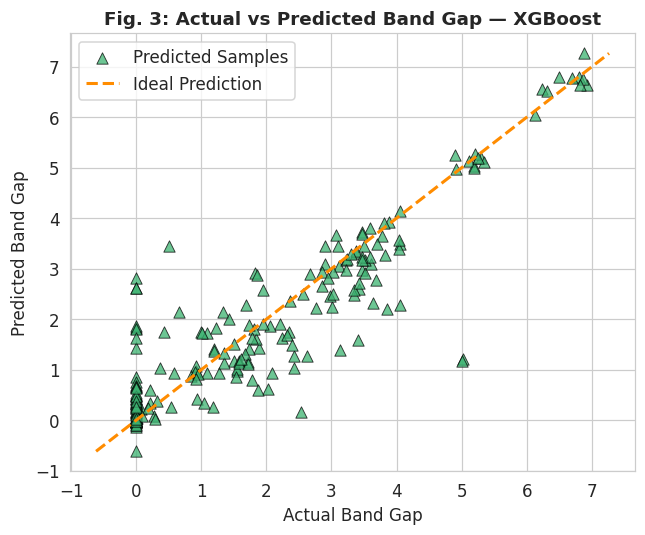

In [35]:
# ─── Fig. 3: Actual vs Predicted Band Gap ───

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

# Actual vs Predicted points
ax.scatter(
    y_test,
    y_pred,
    color="mediumseagreen",   # Different color
    marker="^",               # Diamond shape
    s=55,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.6,
    label="Predicted Samples"
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label="Ideal Prediction"
)

ax.set_xlabel("Actual Band Gap")
ax.set_ylabel("Predicted Band Gap")

ax.set_title(
    f"Fig. 3: Actual vs Predicted Band Gap — {best_name}",
    fontweight="bold",
    fontsize=12
)

ax.legend()

plt.tight_layout()

plt.savefig(
    "fig3_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

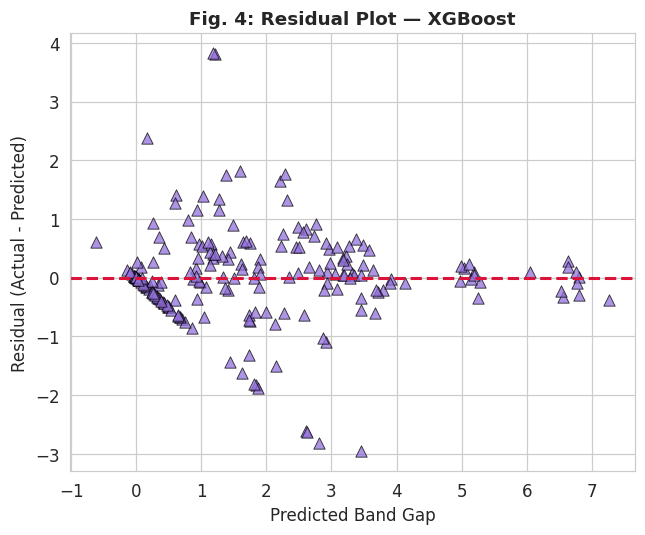

In [36]:
# ─── Fig. 4: Residual Plot ───

import matplotlib.pyplot as plt

# Residuals
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(
    y_pred,
    residuals,
    color="mediumpurple",
    marker="^",          # triangle
    s=55,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.6
)

# Zero-error reference line
ax.axhline(
    y=0,
    color="crimson",
    linestyle="--",
    linewidth=2
)

ax.set_xlabel("Predicted Band Gap")
ax.set_ylabel("Residual (Actual - Predicted)")

ax.set_title(
    f"Fig. 4: Residual Plot — {best_name}",
    fontweight="bold",
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "fig4_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

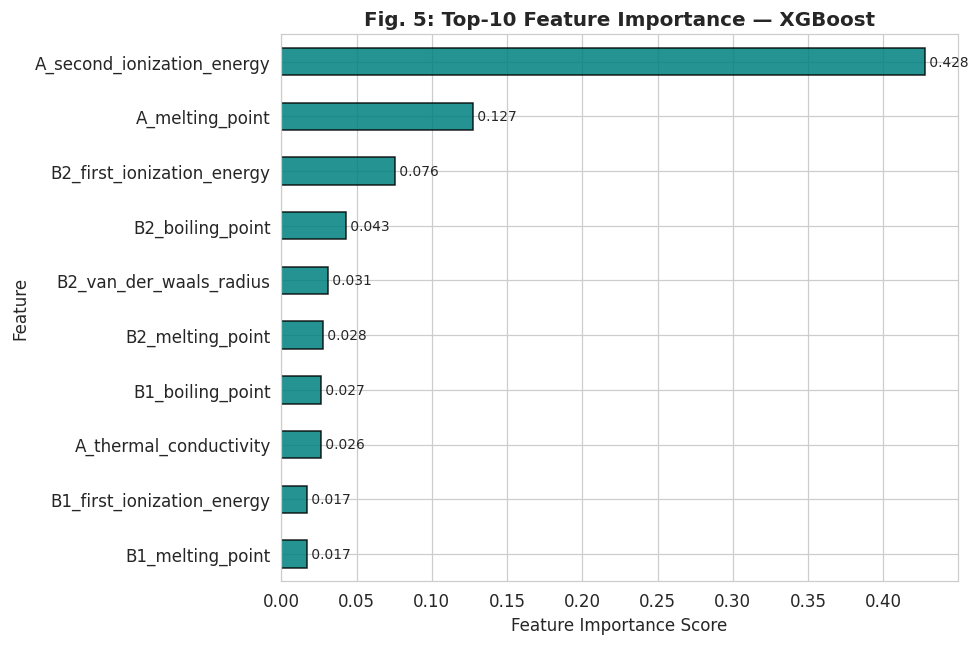

In [37]:
# ─── Fig. 5: Top-10 Feature Importance (Best Model) ───

import pandas as pd
import matplotlib.pyplot as plt

# Extract top-10 feature importances
imp = pd.Series(
    best_mdl.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))

imp.sort_values().plot.barh(
    ax=ax,
    color="teal",
    edgecolor="black",
    alpha=0.85
)

ax.set_title(
    f"Fig. 5: Top-10 Feature Importance — {best_name}",
    fontweight="bold",
    fontsize=13
)

ax.set_xlabel("Feature Importance Score")
ax.set_ylabel("Feature")

# Add importance values beside bars
for i, value in enumerate(imp.sort_values()):
    ax.text(
        value,
        i,
        f" {value:.3f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "fig5_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

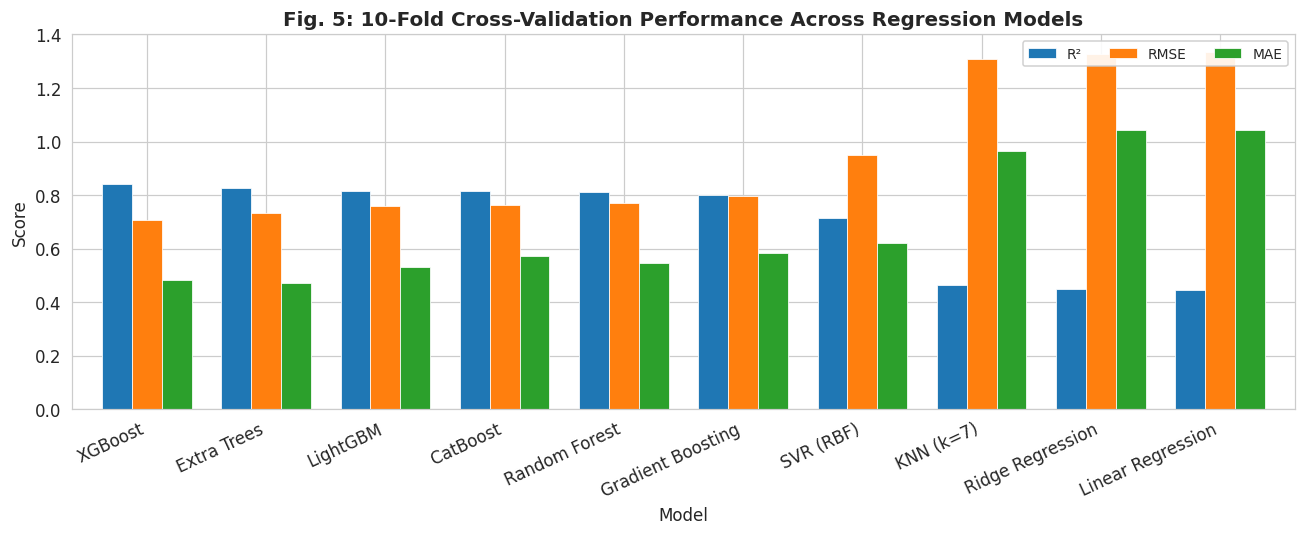

In [43]:
# ─── Fig. 5: 10-Fold CV Metric Comparison Bar Chart ───

# Best model first based on highest CV R²
plot_df = (
    cv_df
    .sort_values("CV R²", ascending=False)
    .set_index("Model")[["CV R²", "CV RMSE", "CV MAE"]]
)

# Rename only for cleaner legend
plot_df.columns = ["R²", "RMSE", "MAE"]

fig, ax = plt.subplots(figsize=(12, 5))

plot_df.plot(
    kind="bar",
    ax=ax,
    width=0.75,
    edgecolor="white",
    linewidth=0.5
)

ax.set_ylabel("Score")

ax.set_title(
    "Fig. 5: 10-Fold Cross-Validation Performance Across Regression Models",
    fontweight="bold",
    fontsize=13
)

ax.legend(
    loc="upper right",
    fontsize=9,
    ncol=3,
    framealpha=0.9
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=25,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "fig5_cv_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
# ─────────────────────────────────────────────
# SHAP Values for Best CV Model
# ─────────────────────────────────────────────

import pandas as pd
import shap

# Convert scaled test data to DataFrame
X_test_s_df = pd.DataFrame(
    X_test_s,
    columns=X.columns,
    index=X_test.index
)

# Best model from 5-fold CV results
best = cv_df.iloc[0]["Model"]
best_model = models[best]

# Fit the selected model on full training data
best_model.fit(X_train_s, y_train)

# Use full test set for SHAP
sample = X_test_s_df.copy()

# Tree-based SHAP explainer
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values
sv = explainer(sample)

print("Best model:", best)
print("Sample shape:", sample.shape)
print("SHAP shape:", sv.values.shape)
print("Feature names:", sv.feature_names)

Best model: XGBoost
Sample shape: (211, 40)
SHAP shape: (211, 40)
Feature names: ['formation_energy', 'A_ionic_radius', 'B1_ionic_radius', 'B2_ionic_radius', 'X_ionic_radius', 'A_electronegativity', 'B1_electronegativity', 'B2_electronegativity', 'X_electronegativity', 'A_atomic_mass', 'B1_atomic_mass', 'B2_atomic_mass', 'X_atomic_mass', 'A_electron_affinity', 'B1_electron_affinity', 'B2_electron_affinity', 'X_electron_affinity', 'A_first_ionization_energy', 'B1_first_ionization_energy', 'B2_first_ionization_energy', 'A_second_ionization_energy', 'B1_second_ionization_energy', 'B2_second_ionization_energy', 'A_melting_point', 'B1_melting_point', 'B2_melting_point', 'A_thermal_conductivity', 'B1_thermal_conductivity', 'B2_thermal_conductivity', 'X_thermal_conductivity', 'A_boiling_point', 'B1_boiling_point', 'B2_boiling_point', 'A_van_der_waals_radius', 'B1_van_der_waals_radius', 'B2_van_der_waals_radius', 'A_third_ionization_energy', 'B1_third_ionization_energy', 'B2_third_ionization_e

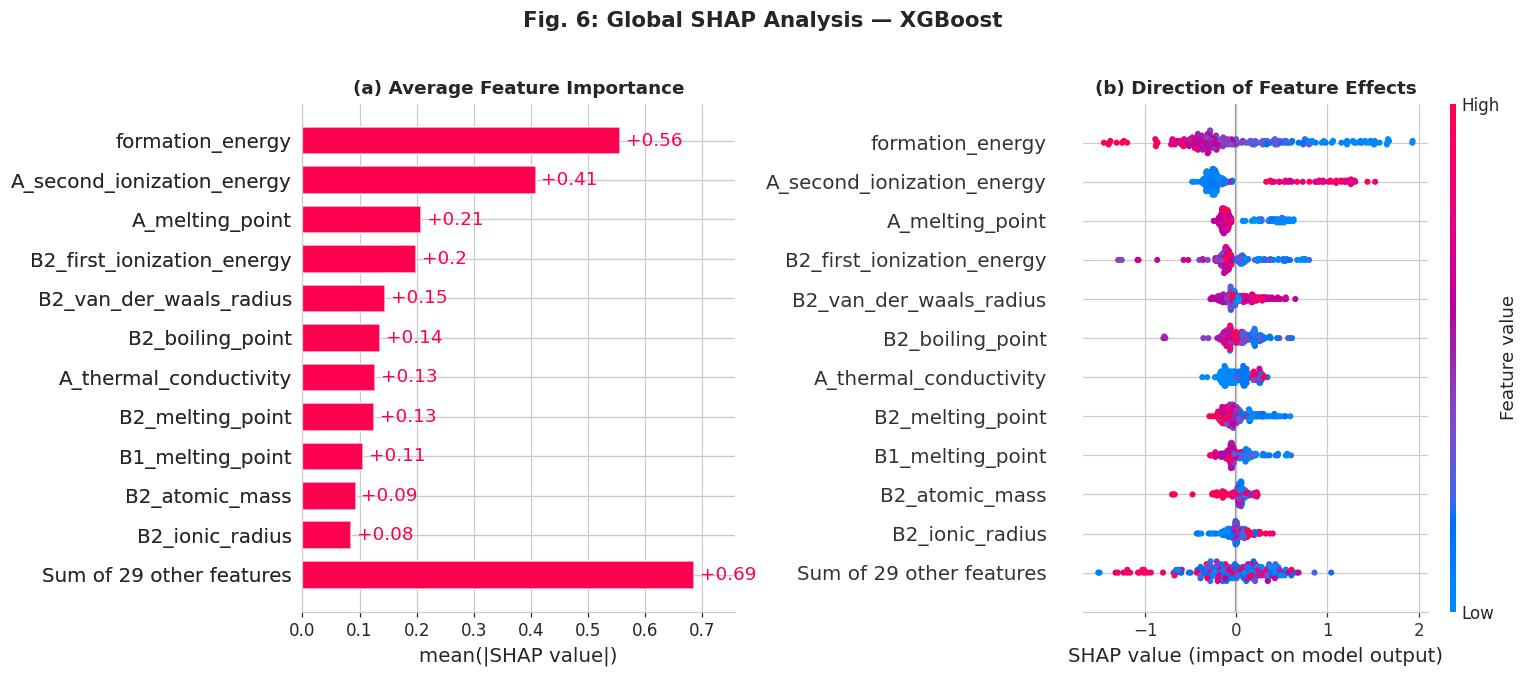

In [45]:
# ─── Fig. 6: Global SHAP Interpretation ───

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# (a) Global feature importance
shap.plots.bar(
    sv,
    max_display=12,
    ax=ax[0],
    show=False
)

ax[0].set_title(
    "(a) Average Feature Importance",
    fontweight="bold",
    fontsize=12
)

# (b) Direction of feature effects
shap.plots.beeswarm(
    sv,
    max_display=12,
    ax=ax[1],
    show=False,
    plot_size=None
)

ax[1].set_title(
    "(b) Direction of Feature Effects",
    fontweight="bold",
    fontsize=12
)

fig.suptitle(
    f"Fig. 6: Global SHAP Analysis — {best}",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

fig.tight_layout()

fig.savefig(
    "fig6_shap_global.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Top-4 SHAP Features:
['formation_energy', 'A_second_ionization_energy', 'A_melting_point', 'B2_first_ionization_energy']


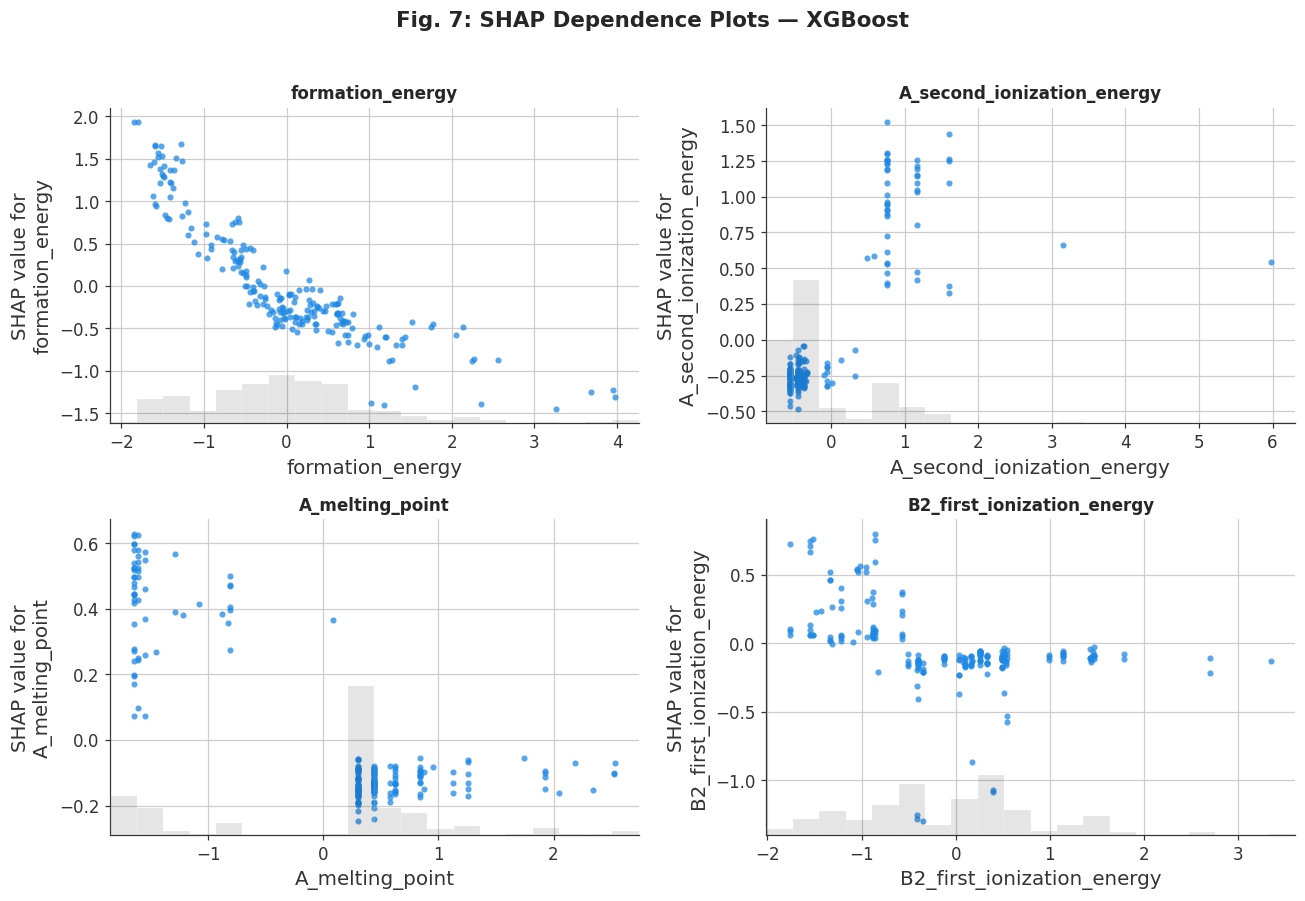

In [46]:
# ─────────────────────────────────────────────
# Fig. 7: SHAP Dependence Plots for Top-4 Features
# ─────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Top-4 features based on mean absolute SHAP value
top4 = (
    pd.Series(
        np.abs(sv.values).mean(axis=0),
        index=sample.columns
    )
    .nlargest(4)
    .index
)

print("Top-4 SHAP Features:")
print(list(top4))

# Create 2 × 2 figure
fig, ax = plt.subplots(
    2, 2,
    figsize=(12, 8)
)

# SHAP dependence plots
for a, feature in zip(ax.ravel(), top4):

    shap.plots.scatter(
        sv[:, feature],
        ax=a,
        show=False,
        alpha=0.75
    )

    a.set_title(
        feature,
        fontweight="bold",
        fontsize=11
    )

fig.suptitle(
    f"Fig. 7: SHAP Dependence Plots — {best}",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

fig.tight_layout()

fig.savefig(
    "fig7_shap_dependence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

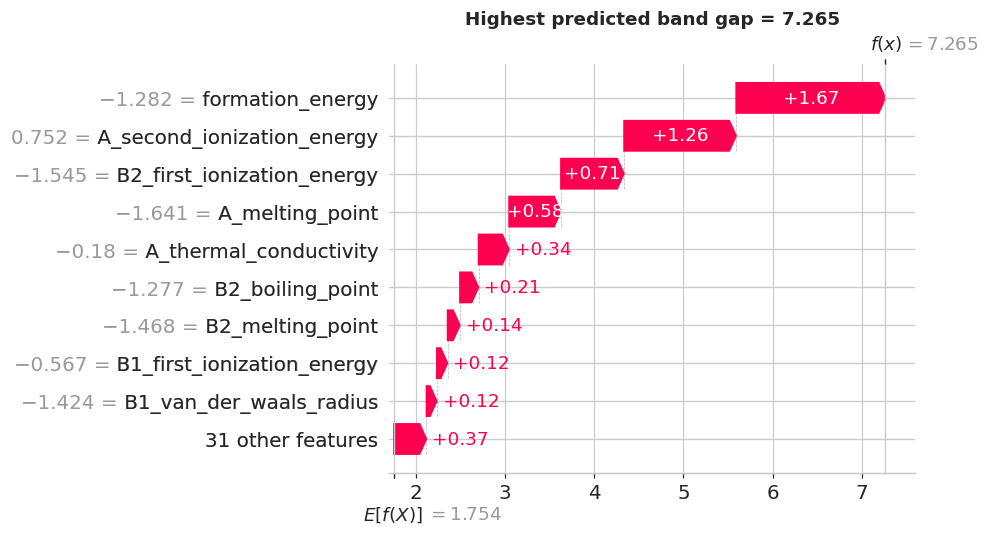

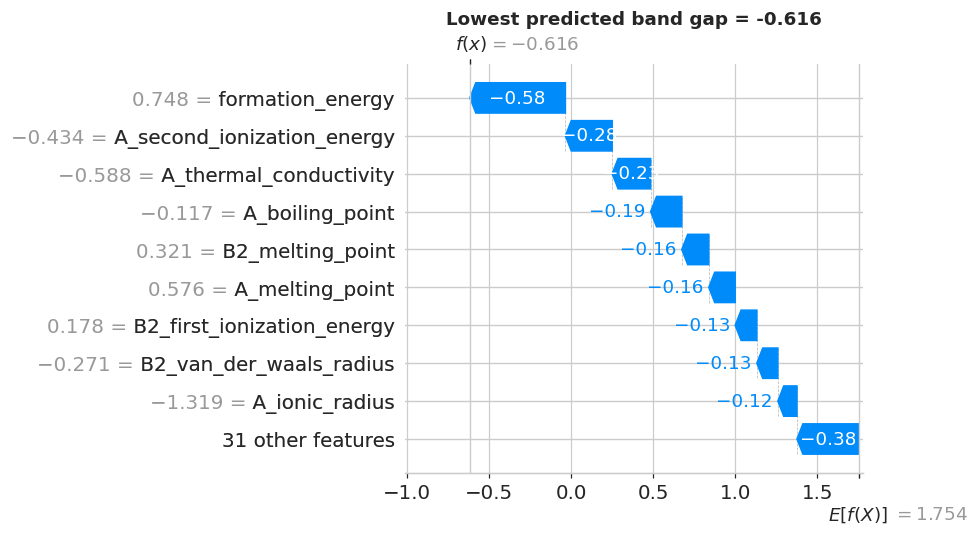

In [47]:
# ─────────────────────────────────────────────
# Local SHAP Explanation:
# Highest and Lowest Predicted Band Gap
# ─────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt

# Predicted band-gap values from the SAME best model
pred_sample = best_model.predict(sample)

# Find highest- and lowest-predicted observations
cases = {
    "Highest predicted band gap": int(np.argmax(pred_sample)),
    "Lowest predicted band gap": int(np.argmin(pred_sample))
}

for label, i in cases.items():

    # Create waterfall plot for one observation
    shap.plots.waterfall(
        sv[i],
        max_display=10,
        show=False
    )

    plt.title(
        f"{label} = {pred_sample[i]:.3f}",
        fontweight="bold",
        fontsize=12
    )

    plt.gcf().set_size_inches(9, 5)

    plt.tight_layout()

    plt.savefig(
        f"fig8_{label.split()[0].lower()}_bandgap.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

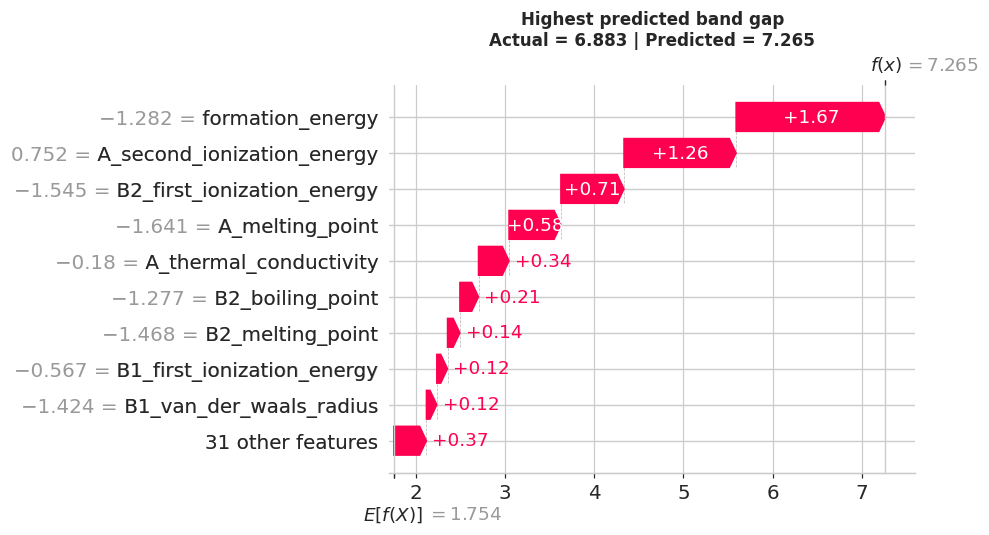

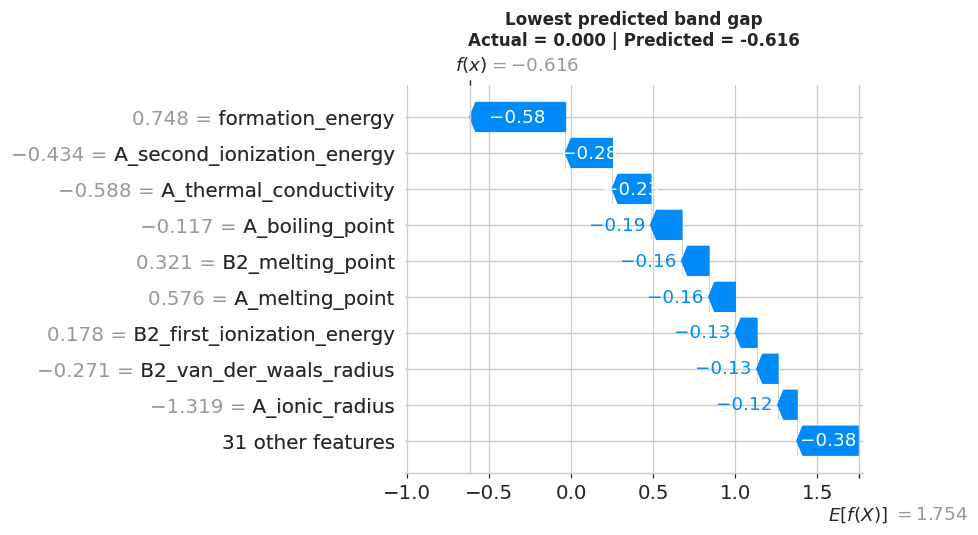

In [48]:
# ─────────────────────────────────────────────
# Local SHAP Explanation with Actual vs Predicted
# ─────────────────────────────────────────────

pred_sample = best_model.predict(sample)

cases = {
    "Highest predicted band gap": int(np.argmax(pred_sample)),
    "Lowest predicted band gap": int(np.argmin(pred_sample))
}

for label, i in cases.items():

    actual_value = y_test.iloc[i]
    predicted_value = pred_sample[i]

    shap.plots.waterfall(
        sv[i],
        max_display=10,
        show=False
    )

    plt.title(
        f"{label}\n"
        f"Actual = {actual_value:.3f} | "
        f"Predicted = {predicted_value:.3f}",
        fontweight="bold",
        fontsize=11
    )

    plt.gcf().set_size_inches(9, 5)

    plt.tight_layout()

    plt.savefig(
        f"fig8_{label.split()[0].lower()}_bandgap.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [49]:
from joblib import dump

# ─────────────────────────────────────────────
# Save Best CV Model + Preprocessing
# ─────────────────────────────────────────────

# Best model from cross-validation
best = cv_df.iloc[0]["Model"]
best_model = models[best]

print("Best model:", best)

# Fit best model on full training set
best_model.fit(X_train_s, y_train)

# Save everything needed for future prediction
model_bundle = {
    "model": best_model,
    "scaler": scaler,
    "features": list(X.columns),
    "target": "band_gap"
}

save_path = OUT / "best_bandgap_model.joblib"

dump(
    model_bundle,
    save_path
)

print("✅ Model saved to:", save_path)

Best model: XGBoost
✅ Model saved to: outputs/best_bandgap_model.joblib
